# SAS821S Capstone T08 - Mining Remote Operations and Industrial-IoT Intrusion Analytics
**Group:** 222093471 Sophia Kalume (Member A, data & modelling) · 215103815 Lasarus Shithindi (Member B, security engineering & intelligence)

This notebook walks through the implemented pipeline and reproduces every number used in the
report and the presentation. It reads the outputs written by `python src/run_all.py`.

**Data status:** ToN_IoT (UNSW Canberra) research captures are real; the remote-access log,
maintenance tickets, asset inventory and user directory are **synthetic**, generated by
documented rules with a fixed seed. The four abnormal access patterns were injected on
purpose and are used as ground truth. Nothing here describes a real organisation or a real
incident.

In [1]:
import json, pandas as pd
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
T, F, P = ROOT/'outputs'/'tables', ROOT/'outputs'/'figures', ROOT/'data'/'processed'
def tbl(n): return pd.read_csv(T/n)
def js(n): return json.loads((T/n).read_text())
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 40)

## Step 1-2 · Data inventory and requirement coverage

In [2]:
inv = tbl('data_inventory.csv')
print('total records:', f"{inv['rows'].sum():,}")
display(inv[['dataset','rows','columns','data_status','project_role','time_from','time_to','labelled']])
display(tbl('minimum_data_check.csv'))

total records: 635,833


,dataset,rows,columns,data_status,project_role,time_from,time_to,labelled
0,iot_fridge,59944,7,public research dataset,IIoT telemetry,2019-03-31 19:36:52,2019-04-29 08:13:08,True
1,iot_garage_door,59587,7,public research dataset,IIoT telemetry,2019-03-31 19:36:52,2019-04-29 06:55:18,True
2,iot_gps_tracker,58960,7,public research dataset,IIoT telemetry,2019-03-31 19:36:52,2019-04-28 18:44:04,True
3,iot_modbus,51106,9,public research dataset,IIoT telemetry (OT protocol),2019-03-31 19:36:52,2019-04-28 19:40:18,True
4,iot_motion_light,59488,7,public research dataset,IIoT telemetry,2019-03-31 19:36:52,2019-04-29 04:26:44,True
5,iot_thermostat,52774,7,public research dataset,IIoT telemetry,2019-03-31 19:36:52,2019-04-29 05:12:49,True
6,iot_weather,59260,8,public research dataset,IIoT telemetry,2019-03-31 19:36:52,2019-04-28 20:59:39,True
7,network_flow,211043,44,public research dataset,Network activity,NaN,NaN,True
8,access_log,22686,18,SYNTHETIC,Identity/access activity,2019-04-01 00:38:39,2019-05-01 00:42:38,False
9,asset_inventory,194,11,SYNTHETIC,Asset/device context,NaN,NaN,False


,requirement,measured,threshold,status
0,At least three distinct security data sources,"5 source families: IIoT telemetry, network flo...",>= 3,MET
1,"At least 5,000 combined event/transaction records","635,833 records across 13 files",">= 5,000",MET
2,At least one labelled dataset (recommended >= ...,"IIoT telemetry 401,119 labelled rows; network ...",">= 1,000",MET
3,At least one unlabelled/semi-labelled dataset ...,"Synthetic remote-access log 22,686 events with...",>= 1 dataset,MET
4,At least 200 unstructured text records,677 records (320 tickets + 357 ATT&CK ICS desc...,>= 200,MET
5,Documented asset/user/device/account/service c...,"194 assets and 114 user accounts with site, zo...",documented,MET


## Step 3 · Cleaning log (what was changed and why)

In [3]:
clog = tbl('cleaning_log.csv')
print(len(clog), 'logged actions')
display(clog.head(15))
display(tbl('data_quality.csv').head(10))

37 logged actions


,dataset,action,detail,reason,rows_before,rows_after
0,iot_fridge,strip_whitespace_bom,all object columns,raw files contain a BOM and padded values such...,59944.0,59944
1,iot_fridge,drop_redundant_columns,"date, time",both duplicate the information already held in ts,59944.0,59944
2,iot_fridge,standardise_category,temp_condition,case and spacing varied between records,59944.0,59944
3,iot_fridge,flag_exact_duplicates,8901 rows flagged,identical ts and values; kept but flagged so m...,59944.0,59944
4,iot_garage_door,strip_whitespace_bom,all object columns,raw files contain a BOM and padded values such...,59587.0,59587
5,iot_garage_door,drop_redundant_columns,"date, time",both duplicate the information already held in ts,59587.0,59587
6,iot_garage_door,coerce_numeric,sphone_signal: 35000 values to NaN,non-numeric text found in a measurement column,59587.0,59587
7,iot_garage_door,standardise_category,door_state,case and spacing varied between records,59587.0,59587
8,iot_garage_door,flag_exact_duplicates,38836 rows flagged,identical ts and values; kept but flagged so m...,59587.0,59587
9,iot_garage_door,retain_missing,sphone_signal: 35000 NaN,"gaps are treated as missing telemetry, not imp...",59587.0,59587


,dataset,issue,detail,value
0,iot_fridge,duplicate_rows,full-row duplicates,8901.00
1,iot_garage_door,duplicate_rows,full-row duplicates,38836.00
2,iot_modbus,duplicate_rows,full-row duplicates,19744.00
3,iot_motion_light,duplicate_rows,full-row duplicates,28629.00
4,iot_thermostat,duplicate_rows,full-row duplicates,1154.00
5,network_flow,duplicate_rows,full-row duplicates,20569.00
6,access_log,high_missingness,gt_scenario,99.52
7,tickets,constant_column,data_status,1.00
8,attack_ics_text,high_missingness,platforms,89.36
9,attack_ics_text,constant_column,source,1.00


## Step 4 · Baselines and exploratory findings

,area,finding,evidence,interpretation
0,IIoT telemetry,Attack-labelled readings are not uniformly ext...,highest separation: weather/pressure with 26.4...,Simple threshold alarms on sensor values alone...
1,Network flows,Connection state separates attack-labelled tra...,"state 'rej' carries 44,852 flows of which 100....",Half-open and rejected connections are the fin...
2,Remote access,A small number of user-days break the behaviou...,45 of 2792 user-days (1.6%) show either >= 3 f...,"These are candidates for investigation, not co..."
3,Remote access,Baseline authentication failure rate,2.01% of all access events are failures (455 o...,This is the reference level any alerting thres...


,role,users,user_days,mean_events,sd_events,mean_failures,p95_failures,mean_ooh,mean_distinct_ips,mean_bytes_out
0,contractor_surveyor,12,254,7.36,4.42,0.18,1.0,1.08,2.33,9109889.72
1,control_room_operator,26,685,9.43,5.66,0.17,1.0,4.38,1.93,11004965.84
2,it_service_desk,10,242,7.81,4.67,0.13,1.0,1.08,1.82,8976073.29
3,maintenance_engineer,24,570,7.47,4.81,0.16,1.0,1.92,1.90,8797768.13
4,mine_planner,14,338,7.90,4.94,0.17,1.0,0.87,1.86,9291605.21
5,ot_network_admin,8,216,8.94,5.70,0.19,1.0,2.57,1.91,10433829.59
6,supervisor,11,271,7.57,5.04,0.13,1.0,2.66,2.01,9129177.03
7,vendor_technician,9,216,7.20,4.59,0.19,1.0,1.69,1.70,9012596.42


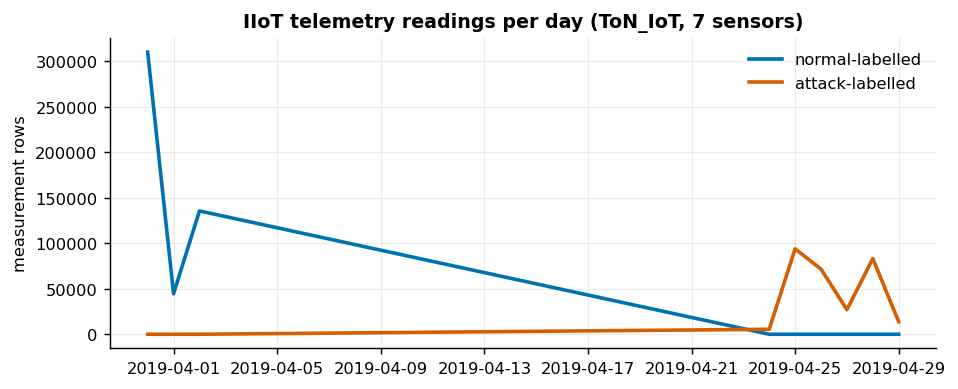

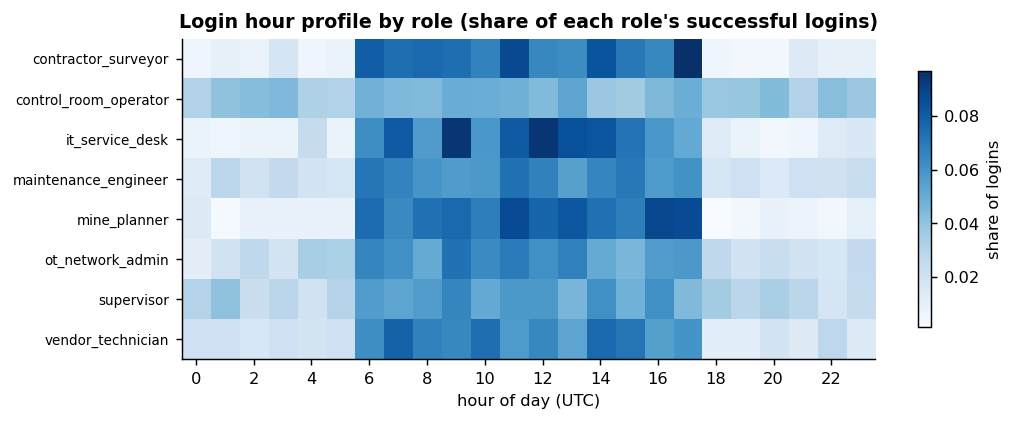

In [4]:
display(tbl('eda_findings.csv'))
display(tbl('baseline_access_role.csv').round(2))
from IPython.display import Image, display as show
for f in ['fig01_telemetry_volume_over_time.png','fig08_login_hour_by_role.png']:
    show(Image(filename=str(F/f)))

## Step 5 · Supervised detection
Models are compared on cross-validated F1 on the training split; the test split is used once.
Exact duplicate rows are removed **before** the split, otherwise the same flow can appear in
both train and test.

,model,cv_f1_mean,cv_f1_sd
0,random_forest,0.9983,0.0001
1,decision_tree,0.9924,0.0006
2,logistic_regression,0.9690,0.0015


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,logistic_regression,0.9556,0.9934,0.9493,0.9708,0.9944,0.9983
1,decision_tree,0.9923,0.9959,0.9942,0.9951,0.9959,0.9977
2,random_forest,0.9980,0.9987,0.9987,0.9987,1.0000,1.0000


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,logistic_regression,0.6244,0.5735,0.5917,0.5825,0.7852,0.7230
1,random_forest,0.9901,0.9998,0.9779,0.9887,0.9985,0.9985


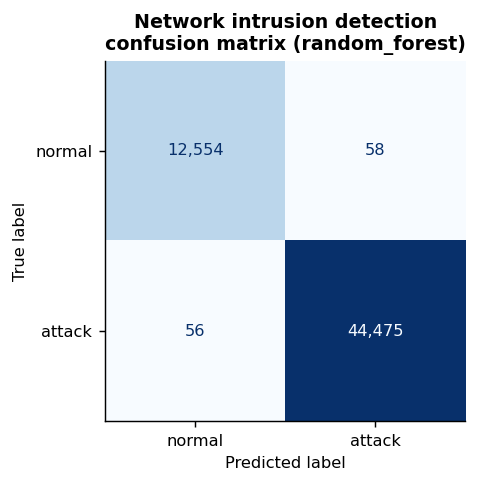

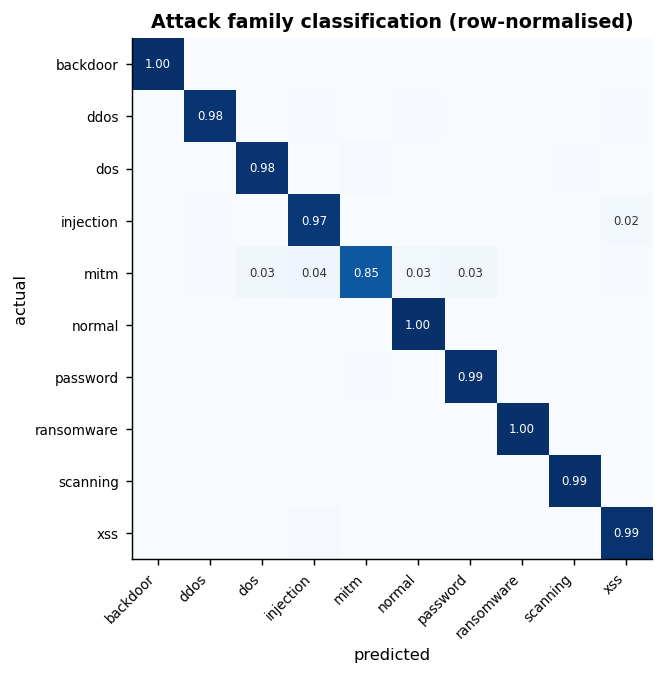

In [5]:
display(tbl('supervised_network_cv.csv').round(4))
display(tbl('supervised_network_test.csv').round(4))
display(tbl('supervised_modbus_test.csv').round(4))
show(Image(filename=str(F/'fig09_confusion_network.png')))
show(Image(filename=str(F/'fig11_confusion_network_multiclass.png')))

## Step 6 · Anomaly detection, and an important negative result
Fully unsupervised outlier detection performs **below chance** on this capture because
attack traffic is the majority class. Learning a clean baseline first fixes it.

In [6]:
a = js('anomaly_summary.json')
print('fully unsupervised ROC-AUC :', round(a['network']['roc_auc_unsupervised'],3))
print('clean-baseline ROC-AUC     :', round(a['network']['roc_auc_clean_baseline'],3))
print(a['network']['interpretation'])
display(tbl('anomaly_access_validation.csv').round(3))
display(tbl('anomaly_access_flagged_user_days.csv').head(10))

fully unsupervised ROC-AUC : 0.279
clean-baseline ROC-AUC     : 0.716
Fully unsupervised outlier detection performs below chance here (ROC-AUC 0.28) because attack traffic is the majority class in this capture. Learning the profile of known-good traffic and scoring novelty against it raises ROC-AUC to 0.72. The operational lesson for the mine is that anomaly detection needs a trusted baseline window, not simply 'whatever is rare today'.


,method,flagged,precision_vs_injected,recall_vs_injected,f1,roc_auc_vs_injected
0,iso,56,0.643,0.818,0.72,0.997
1,lof,56,0.107,0.136,0.12,0.501


,username,role,employment_type,day,events,failures,priv_actions,distinct_ips,distinct_countries,out_of_hours,foreign,bytes_out,iso_score,lof_score,why_flagged,gt
0,cont006,control_room_operator,employee,2019-04-24,13,2,0,4,2,13,3,55140251,0.763106,1.123989,external +10.7 SD vs role mean; foreign +10.7 ...,GT1_password_spray
1,vend069,vendor_technician,vendor,2019-04-25,18,1,4,2,2,8,5,56598662,0.755809,1.609342,distinct_countries +6.5 SD vs role mean; forei...,GT2_vendor_out_of_hours
2,supe112,supervisor,employee,2019-04-24,15,4,3,3,2,5,3,18928693,0.748166,1.097303,distinct_countries +11.6 SD vs role mean; fore...,GT1_password_spray
3,main042,maintenance_engineer,employee,2019-04-24,13,2,0,3,2,9,3,50310783,0.743550,1.037323,external +11.6 SD vs role mean; foreign +11.6 ...,GT1_password_spray
4,cont015,control_room_operator,employee,2019-04-24,12,3,1,3,2,8,3,6442021,0.742691,0.996089,external +10.7 SD vs role mean; foreign +10.7 ...,GT1_password_spray
5,cont080,contractor_surveyor,contractor,2019-04-24,11,3,0,4,2,7,3,11414219,0.737691,0.992923,distinct_countries +6.4 SD vs role mean; failu...,GT1_password_spray
6,cont021,control_room_operator,employee,2019-04-24,22,3,0,2,2,9,3,23075958,0.735210,1.035720,external +10.7 SD vs role mean; foreign +10.7 ...,GT1_password_spray
7,main049,maintenance_engineer,employee,2019-04-24,9,3,2,2,2,3,3,6697652,0.730460,0.991045,external +11.6 SD vs role mean; foreign +11.6 ...,GT1_password_spray
8,vend071,vendor_technician,vendor,2019-04-24,6,3,0,3,2,5,3,5841709,0.730100,1.002676,distinct_countries +6.5 SD vs role mean; failu...,GT1_password_spray
9,cont081,contractor_surveyor,contractor,2019-04-24,3,3,0,1,1,3,3,0,0.729935,1.835354,failures +5.8 SD vs role mean; failure_ratio +...,GT1_password_spray


## Step 7 · Access analytics (UEBA rules with evidence)

In [7]:
display(tbl('ueba_rule_summary.csv').round(3))
display(tbl('ueba_alerts.csv').head(12))

,rule,severity,alerts,accounts,matched_injected,precision_vs_injected
0,R1,medium,11,11,11,1.000
1,R2,high,1,1,1,1.000
2,R3,high,3,3,3,1.000
3,R4,medium,101,30,6,0.059
4,R5,low,41,40,41,1.000
5,R6,high,1,1,1,1.000
6,R7,high,18,2,18,1.000


,alert_id,rule,severity,timestamp,username,asset_id,src_ip,detail,evidence_event_ids,matches_injected_pattern
0,R4-0016,R4,medium,2019-04-01 21:09:58+00:00,ot053,AST-0112,10.36.45.162,"privileged action on file_share at 21:00, outs...",ACC000796,NaN
1,R4-0017,R4,medium,2019-04-01 21:29:17+00:00,ot054,AST-0069,10.54.133.148,privileged action on plc_engineering_ws at 21:...,ACC000805,NaN
2,R4-0018,R4,medium,2019-04-01 23:00:55+00:00,cont023,AST-0008,10.26.192.130,"privileged action on erp at 23:00, outside thi...",ACC000825,NaN
3,R4-0019,R4,medium,2019-04-02 00:18:23+00:00,it059,AST-0162,10.46.74.160,"privileged action on fleet_mgmt at 00:00, outs...",ACC000833,NaN
4,R4-0020,R4,medium,2019-04-02 01:43:46+00:00,ot052,AST-0192,10.24.91.83,privileged action on telemetry_broker at 01:00...,ACC000841,NaN
5,R4-0021,R4,medium,2019-04-02 22:42:34+00:00,ot052,AST-0183,10.24.91.156,"privileged action on file_share at 22:00, outs...",ACC001738,NaN
6,R4-0022,R4,medium,2019-04-02 22:42:57+00:00,ot052,AST-0189,10.24.91.83,privileged action on telemetry_broker at 22:00...,ACC001739,NaN
7,R4-0023,R4,medium,2019-04-03 22:46:39+00:00,cont001,AST-0065,10.51.56.159,"privileged action on erp at 22:00, outside thi...",ACC002586,NaN
8,R4-0024,R4,medium,2019-04-03 23:37:10+00:00,cont015,AST-0042,10.21.208.153,privileged action on maintenance_portal at 23:...,ACC002600,NaN
9,R4-0025,R4,medium,2019-04-04 02:30:19+00:00,ot056,AST-0138,10.51.35.54,"privileged action on cctv_nvr at 02:00, outsid...",ACC002647,NaN


## Step 8 · Investigation
Check the `linkage_basis` column: rows marked CONTEXT ONLY come from a different source
environment and share only the calendar window.

In [8]:
inc = js('incident_summary.json'); print(json.dumps(inc, indent=1)[:900])
display(tbl('incident_timeline.csv').head(15))
display(tbl('incident_response_plan.csv'))

{
 "case_account": "vend069",
 "account_role": "vendor_technician",
 "employment_type": "vendor",
 "alert_window_days": [
  "2019-04-25",
  "2019-04-26",
  "2019-04-27",
  "2019-04-28"
 ],
 "timeline_rows": 202,
 "direct_evidence_rows": 169,
 "context_only_rows": 11,
 "privileged_actions": 16,
 "privileged_without_mfa": 16,
 "affected_assets": 8,
 "injected_pattern_behind_case": [
  "GT2_vendor_out_of_hours"
 ],
 "status": "ANALYTICAL SCENARIO - synthetic access data, testbed context rows",
 "env": {
  "utc_time": "2026-09-19T21:02:09+00:00",
  "python": "3.11.15",
  "platform": "Linux-6.18.44-fc-v37-x86_64-with-glibc2.39",
  "numpy": "2.4.4",
  "pandas": "3.0.2",
  "scikit_learn": "1.8.0",
  "seed": 3815
 }
}


,timestamp,source,event_id,user,user_role,employment_type,asset_id,site,src,dst,event_type,result,privileged,mfa,bytes_out,evidence,linkage_basis,in_alert_window
0,2019-04-02 16:07:24+00:00,remote_access_log (synthetic),ACC001565,vend069,vendor_technician,vendor,AST-0137,WORKSHOP-01,10.32.16.10 (NAM),historian,LOGIN_SUCCESS,success,False,True,0,ACC001565,direct - same account,False
1,2019-04-02 16:39:05+00:00,remote_access_log (synthetic),ACC001579,vend069,vendor_technician,vendor,AST-0124,WORKSHOP-01,10.32.16.10 (NAM),historian,RESOURCE_ACCESS,success,False,True,2682590,ACC001579,direct - same account,False
2,2019-04-02 16:50:08+00:00,remote_access_log (synthetic),ACC001584,vend069,vendor_technician,vendor,AST-0142,WORKSHOP-01,10.32.16.10 (NAM),maintenance_portal,RESOURCE_ACCESS,success,False,True,1239934,ACC001584,direct - same account,False
3,2019-04-02 16:53:06+00:00,remote_access_log (synthetic),ACC001586,vend069,vendor_technician,vendor,AST-0152,WORKSHOP-01,10.32.16.10 (NAM),telemetry_broker,LOGOUT,success,False,True,0,ACC001586,direct - same account,False
4,2019-04-03 07:51:57+00:00,remote_access_log (synthetic),ACC001951,vend069,vendor_technician,vendor,AST-0124,WORKSHOP-01,10.32.16.10 (NAM),historian,LOGIN_SUCCESS,success,False,True,0,ACC001951,direct - same account,False
5,2019-04-03 08:03:03+00:00,remote_access_log (synthetic),ACC001972,vend069,vendor_technician,vendor,AST-0124,WORKSHOP-01,10.32.16.10 (NAM),telemetry_broker,LOGOUT,success,False,True,0,ACC001972,direct - same account,False
6,2019-04-04 10:56:33+00:00,remote_access_log (synthetic),ACC002995,vend069,vendor_technician,vendor,AST-0152,WORKSHOP-01,10.32.16.10 (NAM),cctv_nvr,LOGIN_SUCCESS,success,False,True,0,ACC002995,direct - same account,False
7,2019-04-04 11:08:53+00:00,remote_access_log (synthetic),ACC003007,vend069,vendor_technician,vendor,AST-0133,WORKSHOP-01,10.32.16.10 (NAM),telemetry_broker,RESOURCE_ACCESS,success,False,True,83059,ACC003007,direct - same account,False
8,2019-04-04 11:58:36+00:00,remote_access_log (synthetic),ACC003072,vend069,vendor_technician,vendor,AST-0152,WORKSHOP-01,10.32.16.10 (NAM),telemetry_broker,LOGOUT,success,False,True,0,ACC003072,direct - same account,False
9,2019-04-04 14:35:34+00:00,remote_access_log (synthetic),ACC003232,vend069,vendor_technician,vendor,AST-0142,WORKSHOP-01,10.32.16.10 (NAM),historian,LOGIN_SUCCESS,success,False,True,0,ACC003232,direct - same account,False


,phase,action,evidence_basis
0,Containment,Suspend the remote-access entitlement for vend...,"16 privileged actions in the window, 16 of the..."
1,Containment,Block the external source addresses at the VPN...,non-domestic sources observed: 41.182.90.6 (ZAF)
2,Containment,Place the OT jump host and the engineering wor...,out-of-hours privileged access to OT targets
3,Eradication,Reset credentials and re-enrol MFA for the acc...,authentication occurred without MFA
4,Eradication,Verify the configuration of the assets listed ...,8 assets touched in the window
5,Recovery,Restore vendor access only through a time-boxe...,activity fell outside any approved window
6,Recovery,Confirm normal telemetry and control behaviour...,telemetry context rows in the same window
7,Monitoring,"Keep rules R2, R3, R6 and R7 at high severity ...",R4 produced the majority of alerts at low prec...
8,Monitoring,Alert on any first-seen country for privileged...,R5 matched every injected pattern in the test ...


## Step 9 · Intelligence products

In [9]:
display(tbl('intel_requirements.csv'))
display(tbl('intel_attack_mapping.csv'))
display(tbl('intel_operational_watchlist.csv').head(10))
print((ROOT/'outputs'/'intelligence_executive_brief.md').read_text()[:1800])

,pir,question,sources,review_cycle
0,PIR1,Which remote accounts show behaviour consisten...,"access log, UEBA rules, anomaly model",daily
1,PIR2,Is there evidence of an attacker reaching the ...,"network flows, Modbus telemetry classifier",daily
2,PIR3,Which IIoT devices or network sources deviate ...,"telemetry baselines, Isolation Forest",daily
3,PIR4,Which control package most reduces the chance ...,Monte Carlo simulation,quarterly
4,PIR5,Are maintenance and incident reports describin...,"ticket corpus, ATT&CK enrichment",weekly


,rule,rule_description,rank,attack_id,attack_name,attack_class,similarity,confidence
0,R1,repeated failed authentication attempts agains...,1,DC0002,User Account Authentication,data_component,0.246,moderate
1,R1,repeated failed authentication attempts agains...,2,M0804,Human User Authentication,mitigation,0.193,moderate
2,R2,password spraying from one source address agai...,1,M0927,Password Policies,mitigation,0.363,moderate
3,R2,password spraying from one source address agai...,2,A0015,Switch,asset,0.143,low - reported for context only
4,R3,account authenticating from two distant locati...,1,M0936,Account Use Policies,mitigation,0.141,low - reported for context only
5,R3,account authenticating from two distant locati...,2,M0804,Human User Authentication,mitigation,0.106,low - reported for context only
6,R4,privileged engineering action performed outsid...,1,AN1935,Analytic 1935,analytic,0.207,moderate
7,R4,privileged engineering action performed outsid...,2,T1692.001,Command Message,technique,0.152,moderate
8,R5,account authenticating from a country never se...,1,M0936,Account Use Policies,mitigation,0.244,moderate
9,R5,account authenticating from a country never se...,2,M0804,Human User Authentication,mitigation,0.183,moderate


,username,alerts,rules,highest_sev,last_seen,evidence,max_risk,worst_day,band,top_driver,user_role,employment_type,home_site,privileged_account,mfa_enrolled,priority,attack_context
0,vend069,22,"R3,R4,R5,R7",high,2019-04-28 02:56:00+00:00,ACC018376|ACC018376|ACC018378|ACC018379|ACC018...,98.1,2593.0,critical,external_foreign,vendor_technician,vendor,WORKSHOP-01,False,True,299.1,R3->M0936 Account Use Policies; R4->AN1935 Ana...
1,cont081,8,"R1,R4,R5,R6,R7",high,2019-04-29 04:02:00+00:00,ACC017623|ACC017625|ACC017626|ACC017623|ACC020...,90.9,757.0,critical,external_foreign,contractor_surveyor,contractor,PORT-WVB,False,True,179.9,R1->DC0002 User Account Authentication; R4->AN...
2,main029,9,"R4,R5",medium,2019-04-24 02:37:28+00:00,ACC003546|ACC013192|ACC013198|ACC013205|ACC013...,75.6,1248.0,moderate,anomaly,maintenance_engineer,employee,TAILINGS-01,True,True,157.6,R4->AN1935 Analytic 1935; R5->M0936 Account Us...
3,supe112,6,"R1,R4,R5",medium,2019-04-24 02:32:38+00:00,ACC014123|ACC015691|ACC015692|ACC015694|ACC017...,96.0,2519.0,critical,priv_no_mfa,supervisor,employee,PIT-B,True,False,154.0,R1->DC0002 User Account Authentication; R4->AN...
4,ot054,8,"R4,R5",medium,2019-04-24 02:17:45+00:00,ACC000805|ACC003444|ACC003445|ACC003449|ACC006...,74.5,2196.0,moderate,anomaly,ot_network_admin,employee,PLANT-01,True,True,148.5,R4->AN1935 Analytic 1935; R5->M0936 Account Us...
5,ot051,5,"R3,R4,R5",high,2019-04-28 00:53:25+00:00,ACC006065|ACC011269|ACC020255|ACC020264|ACC020...,76.0,2098.0,high,anomaly,ot_network_admin,employee,PIT-B,True,True,141.0,R3->M0936 Account Use Policies; R4->AN1935 Ana...
6,cont001,7,R4,medium,2019-04-29 22:06:53+00:00,ACC002586|ACC007937|ACC008806|ACC017470|ACC017...,73.6,1.0,moderate,anomaly,control_room_operator,employee,PLANT-01,True,True,139.6,R4->AN1935 Analytic 1935
7,ot052,6,R4,medium,2019-04-16 21:03:26+00:00,ACC000841|ACC001738|ACC001739|ACC006980|ACC006...,76.9,2123.0,high,anomaly,ot_network_admin,employee,PORT-WVB,True,True,134.9,R4->AN1935 Analytic 1935
8,it059,5,R4,medium,2019-04-30 00:52:35+00:00,ACC000833|ACC004343|ACC018356|ACC020956|ACC021742,84.4,961.0,high,priv_no_mfa,it_service_desk,employee,CAMP-01,True,False,134.4,R4->AN1935 Analytic 1935
9,it061,5,"R4,R5",medium,2019-04-24 02:41:07+00:00,ACC005144|ACC008760|ACC014214|ACC017499|ACC017634,80.1,1006.0,high,anomaly,it_service_desk,employee,CAMP-01,True,True,130.1,R4->AN1935 Analytic 1935; R5->M0936 Account Us...


# Executive security brief - Mining remote operations and IIoT

**Prepared by:** SAS821S Capstone group T08 (222093471 Kalume, 215103815 Shithindi)
**Data window:** 1-30 April 2019 (access, ticket and telemetry sources aligned to the same window)
**Status of the data:** ToN_IoT research captures plus a documented synthetic access log. This is a
university exercise; none of the accounts, assets or events describe a real organisation.

## What we found

1. **Remote access is the weakest link in this environment.** 213
   privileged actions took place without multi-factor authentication, and
   56 accounts raised at least one behavioural alert during the month.
   15 user-days scored in the *critical* risk band and 42 in the *high* band
   (out of 2,792 user-days in the month).

2. **The strongest single case** involves account `vend069`
   (vendor_technician, vendor), with
   16 privileged actions of which
   16 had no MFA, touching 8
   assets over 4 days. A containment, eradication,
  

## Step 10 · Control simulation

,scenario,description,runs,p_reach_ot,ci_ot_low,ci_ot_high,p_reach_critical,ci_crit_low,ci_crit_high,mean_assets_compromised,p95_assets_compromised,median_steps_to_ot,abs_reduction_ot,rel_reduction_ot
0,S0_baseline,current controls as described in the asset inv...,5000,0.541,0.527,0.554,0.539,0.525,0.553,29.598,84.0,1.0,0.000,0.000
1,S1_segmentation,IT-OT to OT traffic restricted to approved flows,5000,0.344,0.331,0.357,0.316,0.303,0.329,18.477,60.0,2.0,0.197,0.364
2,S2_strong_auth,MFA enforced for every remote and privileged s...,5000,0.190,0.180,0.202,0.189,0.179,0.200,10.118,61.0,1.0,0.350,0.648
3,S3_monitoring,detection and isolation of a compromised host ...,5000,0.510,0.496,0.523,0.498,0.484,0.511,18.045,54.0,1.0,0.031,0.057
4,S4_combined,all three control packages together,5000,0.100,0.092,0.109,0.082,0.075,0.090,3.004,21.0,2.0,0.440,0.814


,scale,scenario,p_reach_ot,p_reach_critical,mean_assets
0,0.6,S0_baseline,0.443,0.429,15.183
1,0.6,S1_segmentation,0.180,0.133,5.466
2,0.6,S2_strong_auth,0.160,0.157,5.430
3,0.6,S3_monitoring,0.427,0.367,8.291
4,0.6,S4_combined,0.050,0.025,0.958
5,1.0,S0_baseline,0.528,0.527,29.283
6,1.0,S1_segmentation,0.349,0.319,18.682
7,1.0,S2_strong_auth,0.199,0.197,10.202
8,1.0,S3_monitoring,0.518,0.506,17.918
9,1.0,S4_combined,0.098,0.074,2.764


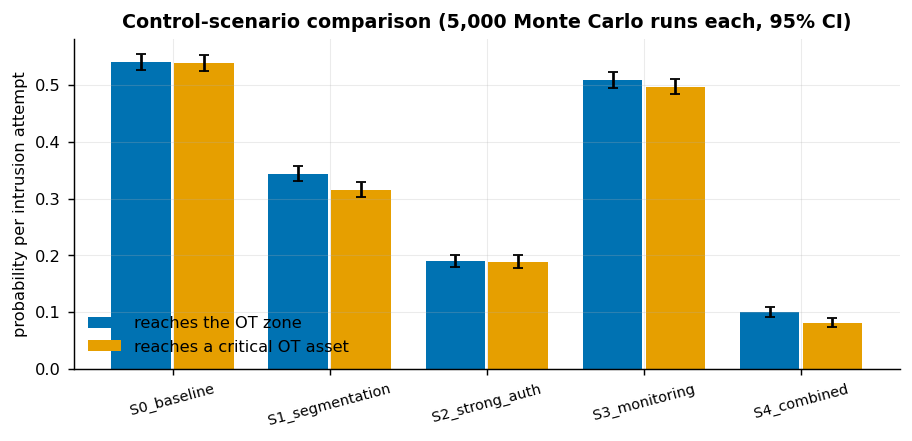

[
 "probabilities are assumed, not measured from mining incidents",
 "no human defender acts during a run except the S3 isolation effect",
 "the graph is generated from a synthetic asset inventory",
 "results compare scenarios; they are not incident-frequency forecasts"
]


In [10]:
display(tbl('simulation_summary.csv').round(3))
display(tbl('simulation_sensitivity.csv').round(3).head(15))
show(Image(filename=str(F/'fig20_simulation_scenarios.png')))
print(json.dumps(js('simulation_summary.json')['limitations'], indent=1))

## Step 11 · Text mining

In [11]:
n = js('nlp_summary.json')
print('corpus:', n['corpus_sizes'])
print('classification macro-F1:', round(n['classification']['macro_f1'],3))
print('CAVEAT:', n['classification']['caveat'])
print('indicator extraction:', {k: round(v,3) for k,v in n['indicator_extraction'].items() if isinstance(v,float)})
display(tbl('nlp_attack_topics.csv'))
display(tbl('nlp_extracted_indicators.csv').head(8))

corpus: {'tickets': 320, 'attack_ics': 357, 'total': 677}
classification macro-F1: 1.0
CAVEAT: The tickets are generated from a template bank, so the vocabulary of each category is highly consistent and the task is far easier than real ticket text. Treat this score as evidence that the pipeline works end to end, not as an estimate of accuracy on real tickets.
indicator extraction: {'precision': 0.972, 'recall': 0.997, 'f1': 0.984}


,topic,top_terms
0,T1,"attack, org, mitre org, attack mitre, https at..."
1,T2,"standard detection, exists technique, method c..."
2,T3,"adversaries, control, devices, adversary, syst..."
3,T4,"communications, help, blocked, technique used,..."
4,T5,"program, management, alarms, monitor, monitor ..."
5,T6,"monitor, network, files, file, traffic, execut..."


,ticket_id,category,ips_found,assets_found,users_found,sites_found,protos_found,malwares_found,n_indicators,gt_entities
0,TKT00023,access_request,NaN,NaN,mine102,PIT-A,NaN,NaN,2,site=PIT-A|target=fleet management portal|user...
1,TKT00132,security_incident,112.238.161.97,AST-0120,it064,NaN,NaN,NaN,3,asset=AST-0120|ip=112.238.161.97|target=PLC en...
2,TKT00297,mechanical,NaN,NaN,NaN,PIT-A,NaN,NaN,1,site=PIT-A
3,TKT00213,mechanical,NaN,NaN,NaN,WORKSHOP-01,NaN,NaN,1,site=WORKSHOP-01
4,TKT00245,security_incident,NaN,NaN,it067,NaN,NaN,NaN,1,target=maintenance portal|user=it067
5,TKT00198,mechanical,NaN,NaN,NaN,PORT-WVB,NaN,NaN,1,site=PORT-WVB
6,TKT00019,access_request,NaN,AST-0125,cont021,NaN,NaN,NaN,2,asset=AST-0125|user=cont021
7,TKT00152,instrumentation,NaN,AST-0182,NaN,PORT-WVB,NaN,NaN,2,asset=AST-0182|site=PORT-WVB


## Step 12-13 · Predictive risk and adversarial testing

,risk_band,user_days,share,injected_rows,mean_score
0,critical,15,0.005,12,89.500
1,high,42,0.015,17,78.850
2,moderate,223,0.080,15,69.990
3,low,2512,0.900,0,47.527


,username,role,employment_type,day,risk_score,risk_band,top_driver,recommended_action,failures,out_of_hours,priv_no_mfa,foreign,bytes_out,iso_score,gt,comp_failures,comp_out_of_hours,comp_external_foreign,comp_priv_no_mfa,comp_anomaly,comp_egress
0,vend069,vendor_technician,vendor,2019-04-25,98.1,critical,anomaly,Investigate now; consider suspending the account,1,8,4.0,5,56598662,0.755809,GT2_vendor_out_of_hours,92.1,94.0,99.9,99.6,100.0,100.0
1,supe112,supervisor,employee,2019-04-24,96.0,critical,anomaly,Investigate now; consider suspending the account,4,5,3.0,3,18928693,0.748166,GT1_password_spray,100.0,82.0,99.6,99.1,99.9,87.1
2,cont081,contractor_surveyor,contractor,2019-04-29,90.9,critical,external_foreign,Investigate now; consider suspending the account,0,11,2.0,7,240784366,0.722848,GT3_dormant_account,43.2,98.0,100.0,98.5,99.6,100.0
3,vend069,vendor_technician,vendor,2019-04-28,90.3,critical,external_foreign,Investigate now; consider suspending the account,0,7,4.0,5,39351134,0.716770,GT2_vendor_out_of_hours,43.2,91.1,99.9,99.6,99.4,99.4
4,cont015,control_room_operator,employee,2019-04-24,90.2,critical,anomaly,Investigate now; consider suspending the account,3,8,1.0,3,6442021,0.742691,GT1_password_spray,99.7,94.0,99.6,97.2,99.9,43.6
5,vend069,vendor_technician,vendor,2019-04-26,89.4,critical,external_foreign,Investigate now; consider suspending the account,0,5,4.0,5,40771399,0.718366,GT2_vendor_out_of_hours,43.2,82.0,99.9,99.6,99.6,99.5
6,vend069,vendor_technician,vendor,2019-04-27,89.3,critical,external_foreign,Investigate now; consider suspending the account,0,5,4.0,5,47315192,0.683505,GT2_vendor_out_of_hours,43.2,82.0,99.9,99.6,98.9,99.8
7,cont006,control_room_operator,employee,2019-04-24,89.2,critical,anomaly,Investigate now; consider suspending the account,2,13,0.0,3,55140251,0.763106,GT1_password_spray,98.7,98.9,99.6,48.1,100.0,99.9
8,main042,maintenance_engineer,employee,2019-04-24,88.9,critical,anomaly,Investigate now; consider suspending the account,2,9,0.0,3,50310783,0.743550,GT1_password_spray,98.7,96.0,99.6,48.1,99.9,99.9
9,cont015,control_room_operator,employee,2019-04-09,88.4,critical,anomaly,Investigate now; consider suspending the account,2,12,3.0,0,25546171,0.707981,NaN,98.7,98.5,49.2,99.1,99.3,94.9


,train_days,test_days,train_rows,test_rows,positive_rate_test,roc_auc,precision_at_20
0,< 2019-04-22,>= 2019-04-22,1945,733,0.082,0.528,0.25


,test,setting,f1,recall_on_attacks,f1_change_vs_baseline
0,T0_baseline,unmodified held-out flows,0.9987,0.9988,0.0000
1,T1_drift_noise,"multiplicative Gaussian noise, sigma=0.05",0.9983,0.9982,-0.0004
2,T1_drift_noise,"multiplicative Gaussian noise, sigma=0.15",0.9953,0.9963,-0.0033
3,T1_drift_noise,"multiplicative Gaussian noise, sigma=0.3",0.9877,0.9873,-0.0110
4,T2_evasion,"attack flows padded x1.5 and slowed x2.0, conn...",0.9986,0.9986,-0.0001
5,T2_evasion,"attack flows padded x3.0 and slowed x5.0, conn...",0.9982,0.9978,-0.0005
6,T2_evasion,"attack flows padded x6.0 and slowed x10.0, con...",0.9977,0.9968,-0.0010
7,T3_missing_data,10% of feature values lost,0.9906,0.9854,-0.0081
8,T3_missing_data,25% of feature values lost,0.9499,0.9169,-0.0488
9,T3_missing_data,50% of feature values lost,0.7728,0.6449,-0.2258


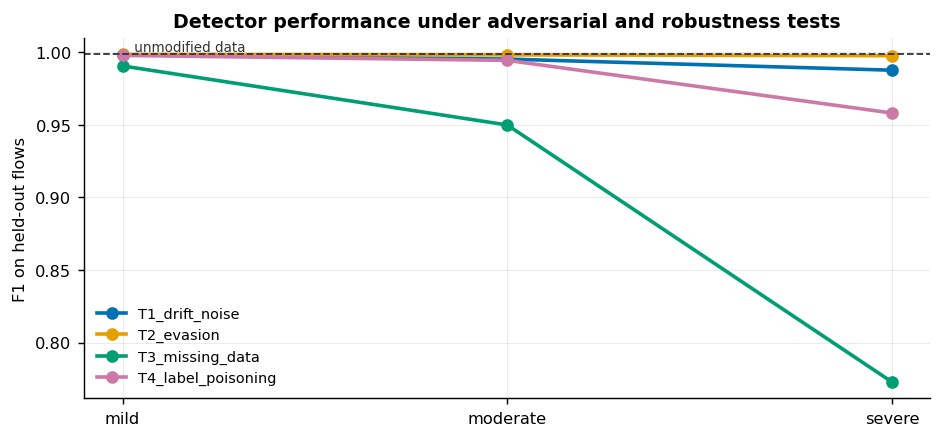

In [12]:
display(tbl('risk_band_summary.csv').round(3))
display(tbl('risk_user_day_scores.csv').head(10))
display(tbl('risk_forecast_metrics.csv').round(3))
display(tbl('adversarial_results.csv').round(4))
show(Image(filename=str(F/'fig25_adversarial_tests.png')))

## Step 15 · Architecture and Step 20 · Compliance

,stage,what_it_does,implemented_in,evidence_files,evidence_present
0,DATA SOURCES,ToN_IoT IIoT telemetry (401k) · ToN_IoT networ...,src/s01-s03,data/raw/attack_ics_text.csv; data/raw/synthet...,2/2
1,INGESTION & INVENTORY,"hashing, profiling, data dictionary, quality f...",src/s04_inventory.py,outputs/tables/data_inventory.csv; outputs/tab...,2/2
2,CLEANING & FEATURES,"placeholder handling, type coercion, duplicate...",src/s06_clean.py,outputs/tables/cleaning_log.csv; data/processe...,2/2
3,DESCRIPTIVE & BASELINE,"volumes, attack mix, service profile, login-ho...",src/s07_eda.py,outputs/tables/baseline_access_role.csv; outpu...,2/2
4,SUPERVISED ML,logistic regression / decision tree / random f...,src/s08_supervised.py,outputs/tables/supervised_network_test.csv,1/1
5,ANOMALY & CLUSTERING,"Isolation Forest (2 framings), LOF, DBSCAN pee...",src/s09_anomaly.py,outputs/tables/anomaly_access_flagged_user_day...,1/1
6,ACCESS ANALYTICS,"7 behaviour rules with evidence, per-user and ...",src/s10_access_analytics.py,outputs/tables/ueba_alerts.csv,1/1
7,INVESTIGATION,"case ranking, correlated timeline, affected en...",src/s11_investigation.py,outputs/tables/incident_timeline.csv,1/1
8,TEXT MINING / NLP,"TF-IDF classification, indicator extraction, N...",src/s14_textmining.py,outputs/tables/nlp_extracted_indicators.csv,1/1
9,INTELLIGENCE,"PIRs, ATT&CK mapping, operational watchlist, e...",src/s12_intelligence.py,outputs/intelligence_executive_brief.md,1/1


,code,requirement,status,files_present,remaining_work
0,C1,Security analytics lifecycle,COMPLETE,5/5,Feedback loop is documented but not yet automa...
1,C2,"Multi-source data (>=3, incl. identity/access ...",COMPLETE,4/4,Access log and tickets are synthetic; this mus...
2,C3,Data engineering and baseline,COMPLETE,5/5,"Network flow source has no timestamp column, s..."
3,C4,Machine learning (supervised + unsupervised),COMPLETE,4/4,Scores on ToN_IoT are high because the capture...
4,C5,Security investigation,COMPLETE,3/3,The case is an analytical scenario built on sy...
5,C6,Security intelligence,COMPLETE,4/4,"ATT&CK mapping is TF-IDF similarity, not an an..."
6,C7,Simulation of >=3 control scenarios,COMPLETE,3/3,Transmission probabilities are assumed; only p...
7,C8,Text mining / NLP,COMPLETE,4/4,"Ticket text is template-generated, so classifi..."
8,C9,Predictive risk + >=3 adversarial tests,COMPLETE,4/4,Next-day forecast is weak (ROC-AUC ~0.53); rep...
9,C10,Decision-support prototype,COMPLETE,3/3,Prototype reads pre-computed outputs; it does ...


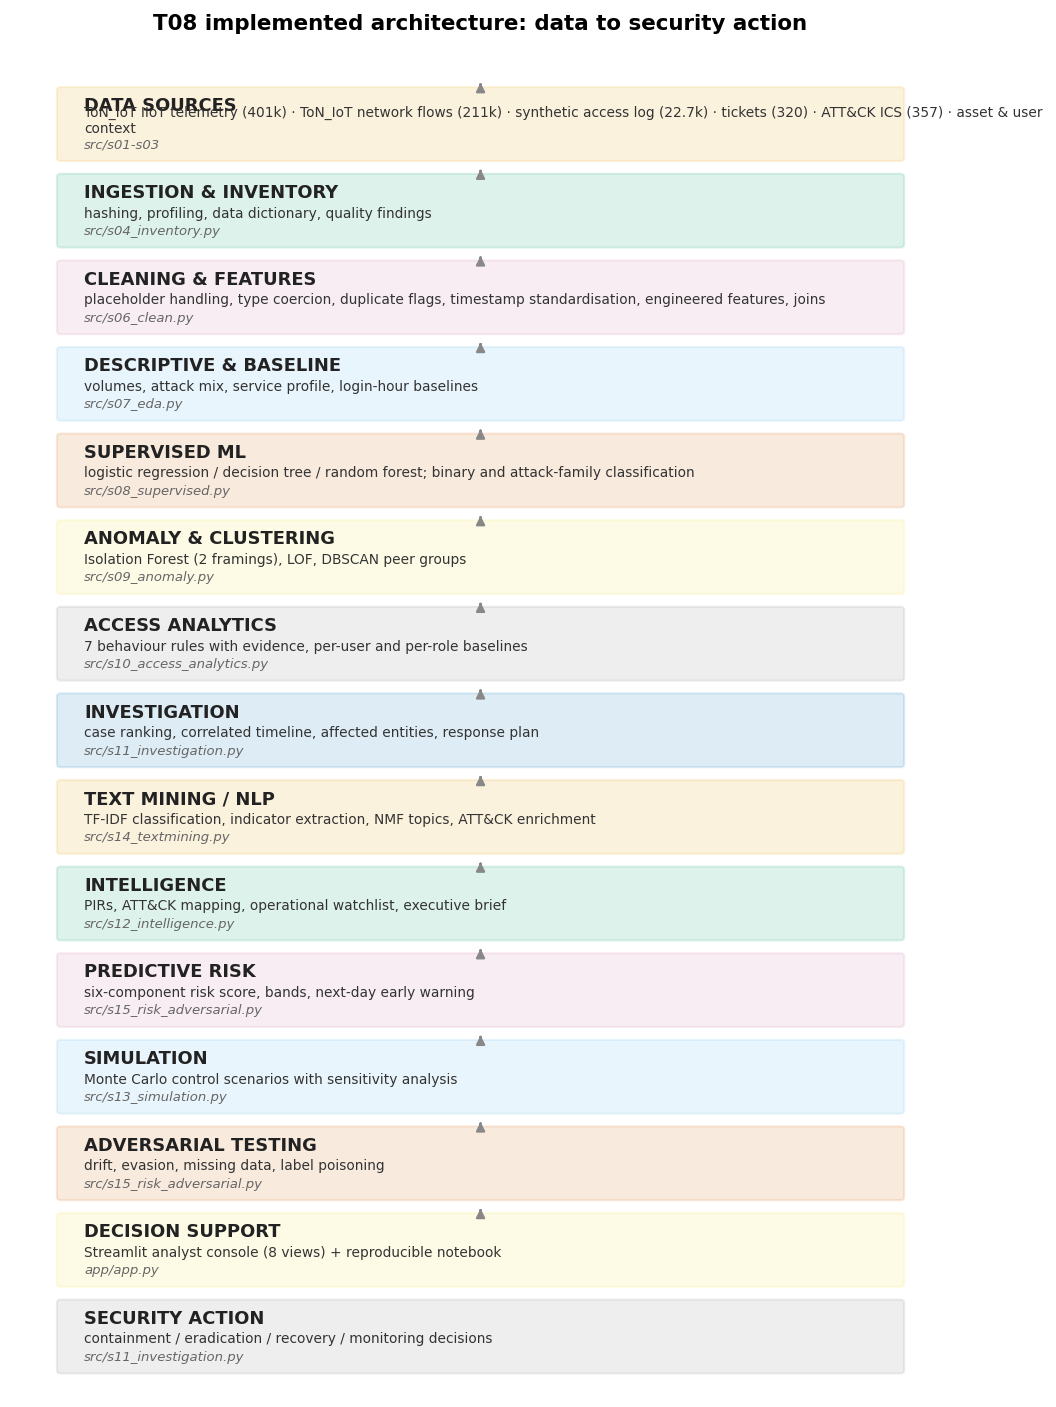

In [13]:
display(tbl('architecture_stages.csv'))
display(tbl('compliance_checklist.csv')[['code','requirement','status','files_present','remaining_work']])
show(Image(filename=str(F/'fig26_architecture.png')))